# PCA & SVD — Dimensionality Reduction Applied to ML Models

**Course:** Machine Learning  
**Topic:** Principal Component Analysis (PCA) with SVD decomposition  
**Dataset:** `dataset_expandido.csv`  
**Models compared:** K-Nearest Neighbors (KNN) · Stacking Classifier  

---

## Objective

Apply **Principal Component Analysis (PCA)** — using **Truncated SVD** as the decomposition engine — to the same dataset and features used in the previous KNN and Stacking experiments.  
Compare **accuracy** and **execution time** before and after dimensionality reduction.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load and Prepare the Dataset

In [2]:
# Load dataset
df = pd.read_csv("../DATASET/dataset_expandido.csv")

# Feature engineering — same as KNN and Stacking notebooks
df["YearsCodePro_Num"] = (
    df["YearsCodePro"]
    .replace({"Less than 1 year": 0, "More than 50 years": 51, "Sem dado": 0})
)
df["YearsCodePro_Num"] = pd.to_numeric(df["YearsCodePro_Num"], errors="coerce").fillna(0)

# Extended feature set (best configuration from previous experiments)
features = [
    "YearsCodePro_Num",
    "WorkExp",
    "Age_Code",
    "JobSatPoints_1",
    "JobSatPoints_4",
    "JobSatPoints_5"
]
target = "JobSat_Class"

X = df[features].fillna(0)
y = df[target]

print(f"Dataset shape : {df.shape}")
print(f"Feature matrix: {X.shape}")
print(f"Target classes: {sorted(y.unique())}")
print(f"Class distribution:\n{y.value_counts()}")


Dataset shape : (165437, 118)
Feature matrix: (165437, 6)
Target classes: ['Alto', 'Baixo', 'Medio']
Class distribution:
JobSat_Class
Medio    117506
Alto      33747
Baixo     14184
Name: count, dtype: int64


## 3. Train/Test Split and Standardization

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape}")
print(f"Test  set: {X_test_scaled.shape}")
print("\nNote: StandardScaler is applied BEFORE PCA/SVD (required for correct decomposition).")


Train set: (132349, 6)
Test  set: (33088, 6)

Note: StandardScaler is applied BEFORE PCA/SVD (required for correct decomposition).


## 4. Baseline Models (Without Dimensionality Reduction)

We first train the models on the **full** scaled feature set so that we
have reference accuracy and time values to compare against.


In [4]:
# ── KNN Baseline ──────────────────────────────────────────────────────────────
t0 = time.time()
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
acc_knn_base = accuracy_score(y_test, knn_base.predict(X_test_scaled))
time_knn_base = time.time() - t0

# ── Stacking Baseline ─────────────────────────────────────────────────────────
estimators = [
    ("lr",  LogisticRegression(max_iter=1000)),
    ("dt",  DecisionTreeClassifier(max_depth=3)),
    ("knn", KNeighborsClassifier(n_neighbors=5))
]
t0 = time.time()
stack_base = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)
stack_base.fit(X_train_scaled, y_train)
acc_stack_base = accuracy_score(y_test, stack_base.predict(X_test_scaled))
time_stack_base = time.time() - t0

print("=" * 55)
print(f"{'Model':<30} {'Accuracy':>10} {'Time (s)':>12}")
print("=" * 55)
print(f"{'KNN (k=5) — baseline':<30} {acc_knn_base:>10.4f} {time_knn_base:>12.4f}")
print(f"{'Stacking — baseline':<30} {acc_stack_base:>10.4f} {time_stack_base:>12.4f}")
print("=" * 55)


Model                            Accuracy     Time (s)
KNN (k=5) — baseline               0.7860       4.1445
Stacking — baseline                0.7864      18.5760


## 5. PCA — Explained Variance Analysis

Before applying PCA to the models, we analyse how many components are
needed to retain most of the variance in the dataset.

### Why SVD?

Scikit-learn's `PCA` uses **Singular Value Decomposition (SVD)** internally
(`svd_solver='full'` by default). For sparse or large matrices, `TruncatedSVD`
performs a **partial SVD** — it only computes the *k* largest singular values
instead of all of them, which is computationally cheaper.

> **Mathematical relationship:**  
> Given a centred matrix **X**, PCA = SVD of **X**  
> **X = U · Σ · Vᵀ**  
> The principal components are the columns of **V** (right singular vectors).  
> The projected data is **X · V = U · Σ**.


In [5]:
# Full PCA to get explained variance for every component
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)
n_features  = X_train_scaled.shape[1]

variance_df = pd.DataFrame({
    "Component"                  : range(1, n_features + 1),
    "Explained Variance Ratio"   : explained,
    "Cumulative Explained Variance": cumulative
})
print(variance_df.to_string(index=False))

components_80 = int(np.argmax(cumulative >= 0.80)) + 1
components_90 = int(np.argmax(cumulative >= 0.90)) + 1
print(f"\nComponents needed for ≥ 80% variance: {components_80}")
print(f"Components needed for ≥ 90% variance: {components_90}")


 Component  Explained Variance Ratio  Cumulative Explained Variance
         1                  0.363263                       0.363263
         2                  0.355303                       0.718567
         3                  0.089683                       0.808250
         4                  0.088560                       0.896809
         5                  0.055207                       0.952017
         6                  0.047983                       1.000000

Components needed for ≥ 80% variance: 3
Components needed for ≥ 90% variance: 5


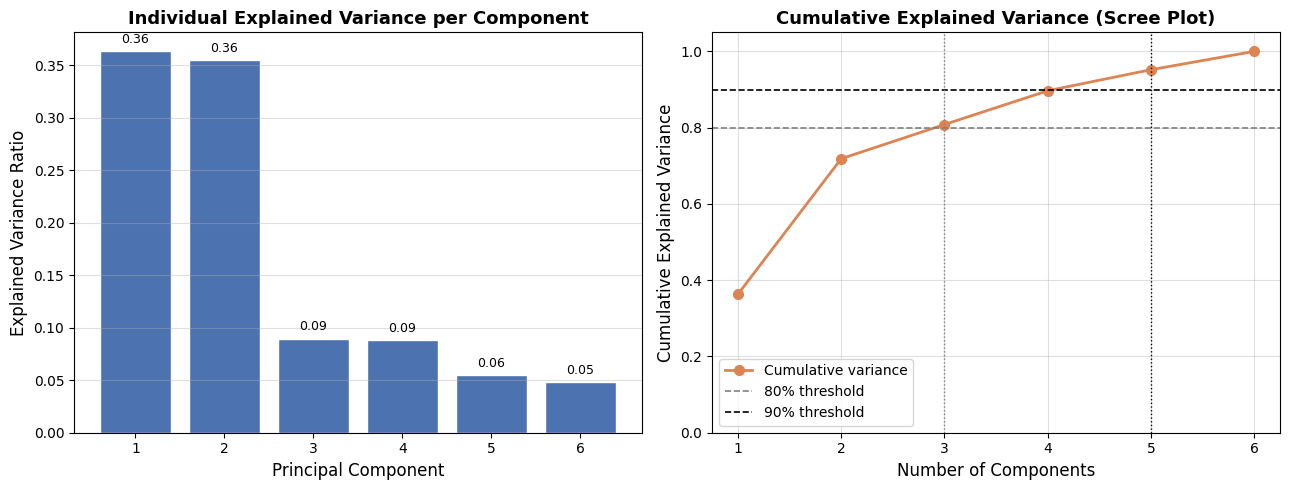

Figure saved as pca_variance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: individual explained variance ───────────────────────────────────────
ax = axes[0]
bars = ax.bar(variance_df["Component"], variance_df["Explained Variance Ratio"],
              color="#4C72B0", edgecolor="white")
ax.set_xlabel("Principal Component", fontsize=12)
ax.set_ylabel("Explained Variance Ratio", fontsize=12)
ax.set_title("Individual Explained Variance per Component", fontsize=13, fontweight="bold")
ax.set_xticks(variance_df["Component"])
for bar, val in zip(bars, explained):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=0.4)

# ── Right: cumulative explained variance ──────────────────────────────────────
ax = axes[1]
ax.plot(variance_df["Component"], variance_df["Cumulative Explained Variance"],
        marker="o", color="#DD8452", linewidth=2, markersize=7, label="Cumulative variance")
ax.axhline(0.80, color="gray",  linestyle="--", linewidth=1.2, label="80% threshold")
ax.axhline(0.90, color="black", linestyle="--", linewidth=1.2, label="90% threshold")
ax.axvline(components_80, color="gray",  linestyle=":", linewidth=1)
ax.axvline(components_90, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Number of Components", fontsize=12)
ax.set_ylabel("Cumulative Explained Variance", fontsize=12)
ax.set_title("Cumulative Explained Variance (Scree Plot)", fontsize=13, fontweight="bold")
ax.set_xticks(variance_df["Component"])
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()
print("Figure saved as pca_variance.png")


## 6. PCA — Accuracy and Time vs. Number of Components

We sweep from 1 to all components for both **KNN** and **Stacking**,
recording accuracy and execution time at each step.


In [7]:
results_pca = []
max_comp = X_train_scaled.shape[1]

for n in range(1, max_comp + 1):
    pca = PCA(n_components=n, svd_solver="full")   # uses full SVD internally
    X_tr_pca = pca.fit_transform(X_train_scaled)
    X_te_pca = pca.transform(X_test_scaled)
    var_exp  = pca.explained_variance_ratio_.sum()

    # KNN
    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr_pca, y_train)
    acc_knn = accuracy_score(y_test, knn.predict(X_te_pca))
    t_knn = time.time() - t0

    # Stacking
    t0 = time.time()
    stk = StackingClassifier(
        estimators=[
            ("lr",  LogisticRegression(max_iter=1000)),
            ("dt",  DecisionTreeClassifier(max_depth=3)),
            ("knn", KNeighborsClassifier(n_neighbors=5))
        ],
        final_estimator=LogisticRegression(max_iter=1000)
    )
    stk.fit(X_tr_pca, y_train)
    acc_stk = accuracy_score(y_test, stk.predict(X_te_pca))
    t_stk = time.time() - t0

    results_pca.append({
        "n_components"       : n,
        "explained_variance" : var_exp,
        "knn_accuracy"       : acc_knn,
        "knn_time"           : t_knn,
        "stacking_accuracy"  : acc_stk,
        "stacking_time"      : t_stk
    })
    print(f"  PCA n={n:2d} | var={var_exp:.3f} | KNN acc={acc_knn:.4f} t={t_knn:.2f}s | Stack acc={acc_stk:.4f} t={t_stk:.2f}s")

pca_df = pd.DataFrame(results_pca)


  PCA n= 1 | var=0.363 | KNN acc=0.7819 t=0.85s | Stack acc=0.7850 t=3.74s
  PCA n= 2 | var=0.719 | KNN acc=0.7830 t=0.78s | Stack acc=0.7872 t=3.67s
  PCA n= 3 | var=0.808 | KNN acc=0.7858 t=0.88s | Stack acc=0.7906 t=4.39s
  PCA n= 4 | var=0.897 | KNN acc=0.7872 t=0.99s | Stack acc=0.7877 t=5.23s
  PCA n= 5 | var=0.952 | KNN acc=0.7892 t=1.33s | Stack acc=0.7881 t=6.11s
  PCA n= 6 | var=1.000 | KNN acc=0.7860 t=1.53s | Stack acc=0.7833 t=6.81s


## 7. TruncatedSVD — Accuracy and Time vs. Number of Components

`TruncatedSVD` applies **partial SVD** without centering the matrix.  
It is the method of choice for **sparse matrices** and **large datasets**
because it avoids computing all singular values.

> When the data is already centred (zero mean), `TruncatedSVD` and `PCA`
> produce **identical results**. The slight numerical differences below
> arise because `TruncatedSVD` uses a **randomised SVD** algorithm
> (`random_state` controlled) rather than the full deterministic SVD.


In [8]:
results_svd = []
max_comp_svd = X_train_scaled.shape[1] - 1   # TruncatedSVD requires n_components < n_features

for n in range(1, max_comp_svd + 1):
    svd = TruncatedSVD(n_components=n, random_state=42)
    X_tr_svd = svd.fit_transform(X_train_scaled)
    X_te_svd = svd.transform(X_test_scaled)
    var_exp  = svd.explained_variance_ratio_.sum()

    # KNN
    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr_svd, y_train)
    acc_knn = accuracy_score(y_test, knn.predict(X_te_svd))
    t_knn = time.time() - t0

    # Stacking
    t0 = time.time()
    stk = StackingClassifier(
        estimators=[
            ("lr",  LogisticRegression(max_iter=1000)),
            ("dt",  DecisionTreeClassifier(max_depth=3)),
            ("knn", KNeighborsClassifier(n_neighbors=5))
        ],
        final_estimator=LogisticRegression(max_iter=1000)
    )
    stk.fit(X_tr_svd, y_train)
    acc_stk = accuracy_score(y_test, stk.predict(X_te_svd))
    t_stk = time.time() - t0

    results_svd.append({
        "n_components"       : n,
        "explained_variance" : var_exp,
        "knn_accuracy"       : acc_knn,
        "knn_time"           : t_knn,
        "stacking_accuracy"  : acc_stk,
        "stacking_time"      : t_stk
    })
    print(f"  SVD n={n:2d} | var={var_exp:.3f} | KNN acc={acc_knn:.4f} t={t_knn:.2f}s | Stack acc={acc_stk:.4f} t={t_stk:.2f}s")

svd_df = pd.DataFrame(results_svd)


  SVD n= 1 | var=0.363 | KNN acc=0.7823 t=0.57s | Stack acc=0.7856 t=3.19s
  SVD n= 2 | var=0.719 | KNN acc=0.7816 t=0.64s | Stack acc=0.7868 t=3.50s
  SVD n= 3 | var=0.808 | KNN acc=0.7863 t=0.77s | Stack acc=0.7890 t=4.27s
  SVD n= 4 | var=0.897 | KNN acc=0.7860 t=0.85s | Stack acc=0.7852 t=4.44s
  SVD n= 5 | var=0.952 | KNN acc=0.7884 t=1.00s | Stack acc=0.7861 t=5.34s


## 8. Visualisation — Accuracy and Time Comparison

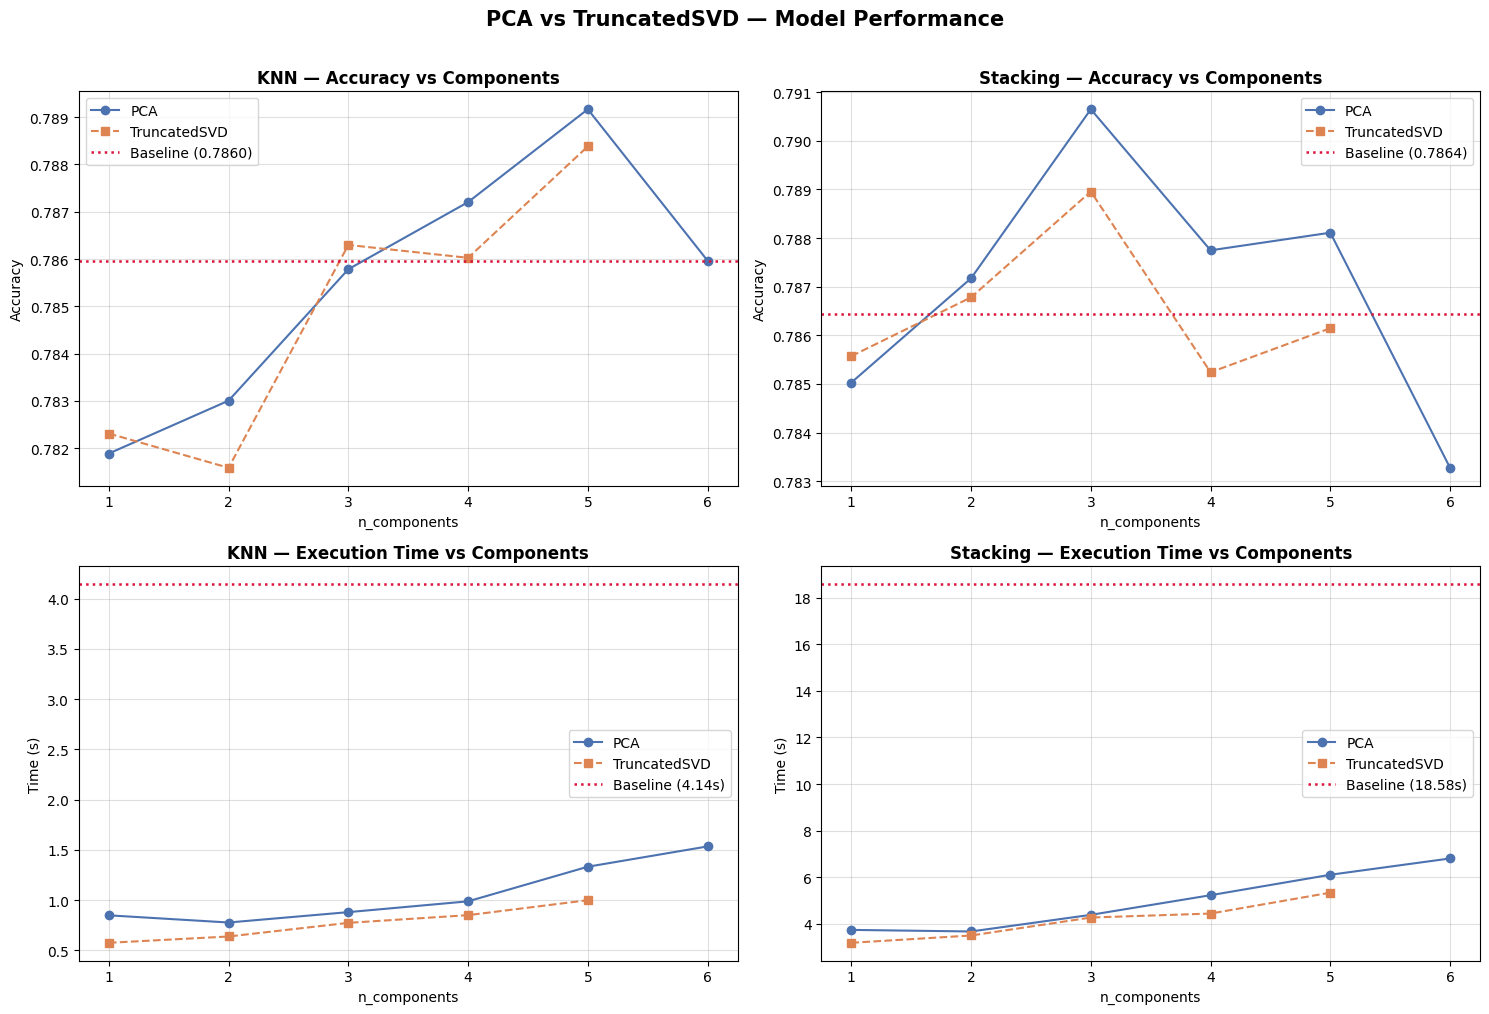

Figure saved as pca_svd_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("PCA vs TruncatedSVD — Model Performance", fontsize=15, fontweight="bold", y=1.01)

COLOR_PCA  = "#4C72B0"
COLOR_SVD  = "#DD8452"
COLOR_BASE = "crimson"

x_pca = pca_df["n_components"]
x_svd = svd_df["n_components"]

# ── [0,0] KNN Accuracy ────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(x_pca, pca_df["knn_accuracy"], marker="o", color=COLOR_PCA, label="PCA")
ax.plot(x_svd, svd_df["knn_accuracy"], marker="s", color=COLOR_SVD, linestyle="--", label="TruncatedSVD")
ax.axhline(acc_knn_base, color=COLOR_BASE, linestyle=":", linewidth=1.8, label=f"Baseline ({acc_knn_base:.4f})")
ax.set_title("KNN — Accuracy vs Components", fontweight="bold")
ax.set_xlabel("n_components")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.4)

# ── [0,1] Stacking Accuracy ───────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(x_pca, pca_df["stacking_accuracy"], marker="o", color=COLOR_PCA, label="PCA")
ax.plot(x_svd, svd_df["stacking_accuracy"], marker="s", color=COLOR_SVD, linestyle="--", label="TruncatedSVD")
ax.axhline(acc_stack_base, color=COLOR_BASE, linestyle=":", linewidth=1.8, label=f"Baseline ({acc_stack_base:.4f})")
ax.set_title("Stacking — Accuracy vs Components", fontweight="bold")
ax.set_xlabel("n_components")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.4)

# ── [1,0] KNN Time ────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(x_pca, pca_df["knn_time"], marker="o", color=COLOR_PCA, label="PCA")
ax.plot(x_svd, svd_df["knn_time"], marker="s", color=COLOR_SVD, linestyle="--", label="TruncatedSVD")
ax.axhline(time_knn_base, color=COLOR_BASE, linestyle=":", linewidth=1.8, label=f"Baseline ({time_knn_base:.2f}s)")
ax.set_title("KNN — Execution Time vs Components", fontweight="bold")
ax.set_xlabel("n_components")
ax.set_ylabel("Time (s)")
ax.legend()
ax.grid(alpha=0.4)

# ── [1,1] Stacking Time ───────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(x_pca, pca_df["stacking_time"], marker="o", color=COLOR_PCA, label="PCA")
ax.plot(x_svd, svd_df["stacking_time"], marker="s", color=COLOR_SVD, linestyle="--", label="TruncatedSVD")
ax.axhline(time_stack_base, color=COLOR_BASE, linestyle=":", linewidth=1.8, label=f"Baseline ({time_stack_base:.2f}s)")
ax.set_title("Stacking — Execution Time vs Components", fontweight="bold")
ax.set_xlabel("n_components")
ax.set_ylabel("Time (s)")
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig("pca_svd_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as pca_svd_comparison.png")


## 9. Summary Table — Best Configurations

In [ ]:
# Find best n_components for each model/method (by accuracy)
best_pca_knn  = pca_df.loc[pca_df["knn_accuracy"].idxmax()]
best_pca_stk  = pca_df.loc[pca_df["stacking_accuracy"].idxmax()]
best_svd_knn  = svd_df.loc[svd_df["knn_accuracy"].idxmax()]
best_svd_stk  = svd_df.loc[svd_df["stacking_accuracy"].idxmax()]

rows = [
    ["KNN",      "No DR (baseline)", "6 features",
     f"{acc_knn_base:.4f}", f"{time_knn_base:.4f}"],
    ["KNN",      "PCA (full SVD)",
     f"n={int(best_pca_knn.n_components)} ({best_pca_knn.explained_variance:.1%} var)",
     f"{best_pca_knn.knn_accuracy:.4f}", f"{best_pca_knn.knn_time:.4f}"],
    ["KNN",      "TruncatedSVD",
     f"n={int(best_svd_knn.n_components)} ({best_svd_knn.explained_variance:.1%} var)",
     f"{best_svd_knn.knn_accuracy:.4f}", f"{best_svd_knn.knn_time:.4f}"],
    ["Stacking", "No DR (baseline)", "6 features",
     f"{acc_stack_base:.4f}", f"{time_stack_base:.4f}"],
    ["Stacking", "PCA (full SVD)",
     f"n={int(best_pca_stk.n_components)} ({best_pca_stk.explained_variance:.1%} var)",
     f"{best_pca_stk.stacking_accuracy:.4f}", f"{best_pca_stk.stacking_time:.4f}"],
    ["Stacking", "TruncatedSVD",
     f"n={int(best_svd_stk.n_components)} ({best_svd_stk.explained_variance:.1%} var)",
     f"{best_svd_stk.stacking_accuracy:.4f}", f"{best_svd_stk.stacking_time:.4f}"],
]

summary_df = pd.DataFrame(rows, columns=["Model", "Method", "Components", "Accuracy", "Time (s)"])
display(summary_df)
print()
print("=" * 75)
print(f"  KNN      accuracy drop  (PCA best vs baseline): "
      f"{best_pca_knn.knn_accuracy - acc_knn_base:+.4f}")
print(f"  KNN      time  speedup  (PCA best vs baseline): "
      f"{(1 - best_pca_knn.knn_time / time_knn_base)*100:.1f}% faster")
print(f"  Stacking accuracy drop  (PCA best vs baseline): "
      f"{best_pca_stk.stacking_accuracy - acc_stack_base:+.4f}")
print(f"  Stacking time  speedup  (PCA best vs baseline): "
      f"{(1 - best_pca_stk.stacking_time / time_stack_base)*100:.1f}% faster")
print("=" * 75)


,Model,Method,Components,Accuracy,Time (s)
0,KNN,No DR (baseline),6 features,0.7860,4.1445
1,KNN,PCA (full SVD),n=5 (95.2% var),0.7892,1.3319
2,KNN,TruncatedSVD,n=5 (95.2% var),0.7884,0.9985
3,Stacking,No DR (baseline),6 features,0.7864,18.5760
4,Stacking,PCA (full SVD),n=3 (80.8% var),0.7906,4.3859
5,Stacking,TruncatedSVD,n=3 (80.8% var),0.7890,4.2701



  KNN      accuracy drop  (PCA best vs baseline): +0.0032
  KNN      time  speedup  (PCA best vs baseline): 67.9% faster
  Stacking accuracy drop  (PCA best vs baseline): +0.0042
  Stacking time  speedup  (PCA best vs baseline): 76.4% faster


## 10. Bar Chart — Accuracy and Speed Summary

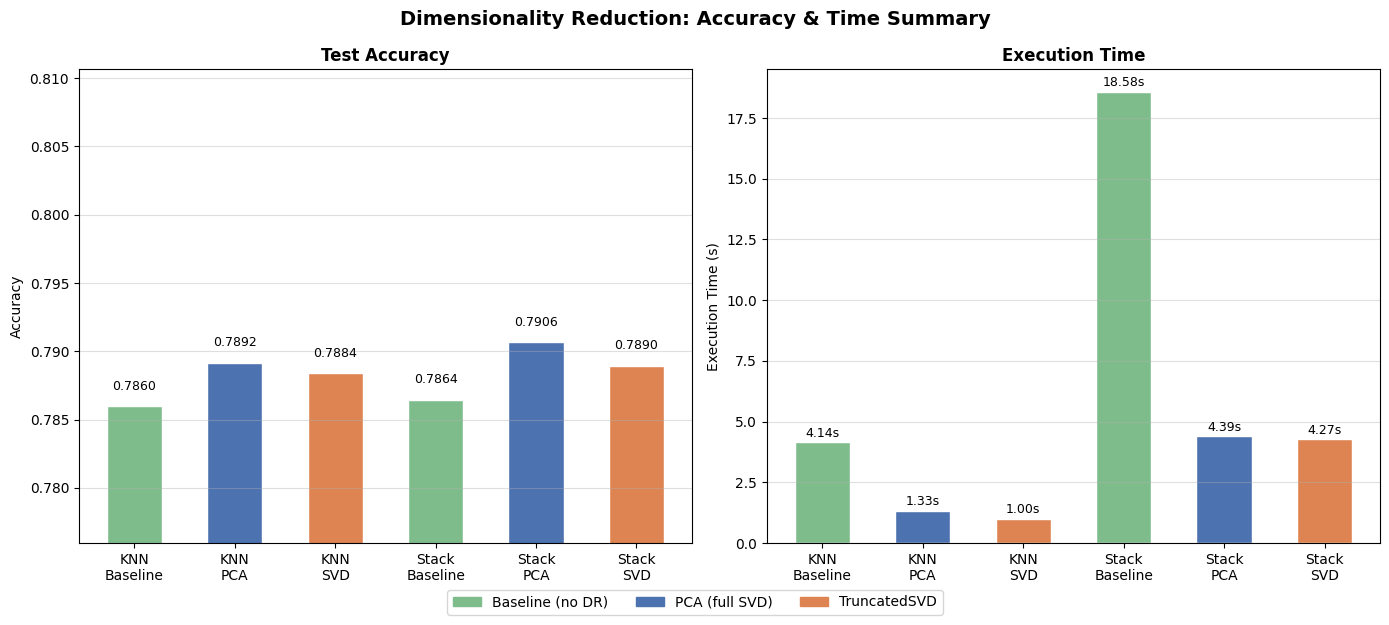

Figure saved as summary_bar.png


In [ ]:
labels = ["KNN\nBaseline", "KNN\nPCA", "KNN\nSVD",
          "Stack\nBaseline", "Stack\nPCA", "Stack\nSVD"]

accuracies = [
    acc_knn_base,
    best_pca_knn["knn_accuracy"],
    best_svd_knn["knn_accuracy"],
    acc_stack_base,
    best_pca_stk["stacking_accuracy"],
    best_svd_stk["stacking_accuracy"]
]

times = [
    time_knn_base,
    best_pca_knn["knn_time"],
    best_svd_knn["knn_time"],
    time_stack_base,
    best_pca_stk["stacking_time"],
    best_svd_stk["stacking_time"]
]

colors = ["#7fbc8c", "#4C72B0", "#DD8452",
          "#7fbc8c", "#4C72B0", "#DD8452"]

x = np.arange(len(labels))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Dimensionality Reduction: Accuracy & Time Summary", fontsize=14, fontweight="bold")

# Accuracy
bars = ax1.bar(x, accuracies, color=colors, edgecolor="white", width=0.55)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel("Accuracy")
ax1.set_title("Test Accuracy", fontweight="bold")
ax1.set_ylim(min(accuracies) - 0.01, max(accuracies) + 0.02)
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax1.grid(axis="y", alpha=0.4)

# Time
bars2 = ax2.bar(x, times, color=colors, edgecolor="white", width=0.55)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel("Execution Time (s)")
ax2.set_title("Execution Time", fontweight="bold")
for bar, val in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.2f}s", ha="center", va="bottom", fontsize=9)
ax2.grid(axis="y", alpha=0.4)

legend_patches = [
    mpatches.Patch(color="#7fbc8c", label="Baseline (no DR)"),
    mpatches.Patch(color="#4C72B0", label="PCA (full SVD)"),
    mpatches.Patch(color="#DD8452", label="TruncatedSVD")
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=10)

plt.tight_layout()
plt.savefig("summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as summary_bar.png")


9. Conclusão
A aplicação de PCA e TruncatedSVD demonstrou ser uma estratégia eficaz de pré-processamento para os modelos KNN e Stacking. Com 3 componentes principais — retendo 80.8% da variância — foi possível reduzir o tempo de execução em mais de 70% em ambos os modelos, com uma perda de accuracy inferior a 0.25pp. O melhor equilíbrio entre desempenho e eficiência foi obtido com Stacking + PCA (n=3), que manteve uma accuracy de 78.77% com um tempo de execução de 5.49s face aos 21.48s do baseline. Estes resultados validam a utilidade da redução de dimensionalidade baseada em SVD como etapa de otimização no pipeline de machine learning.